In [1]:
import rioxarray as rxr
import xarray as xr
import numpy as np
from rasterio.enums import Resampling
import glob
from rioxarray.merge import merge_arrays

In [2]:
print("Hello, World!")

Hello, World!


In [3]:
# ------------------------------------------------------------------
# Read data
# ------------------------------------------------------------------

dem_path = "/Users/Wanja/Downloads/Elevation_raw"
rangeland_path = "/Volumes/TOSHIBA EXT/non-equilibrium/data/test/Rangeland.tif"

# Read all DEM tiles
files = sorted(glob.glob(dem_path + "/*.tif"))

tiles = [
    rxr.open_rasterio(f, masked=True).squeeze()
    for f in files
]

# Merge into one DEM
dem = merge_arrays(tiles)

# MODIS 5 km rangeland raster (already in MODIS sinusoidal projection)
rangeland = rxr.open_rasterio(rangeland_path, masked=True).squeeze()

In [4]:
# ------------------------------------------------------------------
# Aggregate DEM to the MODIS grid
# ------------------------------------------------------------------

# Mean
dem_mean = dem.rio.reproject_match(
    rangeland,
    resampling=Resampling.average
)

# Minimum
dem_min = dem.rio.reproject_match(
    rangeland,
    resampling=Resampling.min
)

# Maximum
dem_max = dem.rio.reproject_match(
    rangeland,
    resampling=Resampling.max
)

# Median
dem_median = dem.rio.reproject_match(
    rangeland,
    resampling=Resampling.med
)

In [5]:
# ------------------------------------------------------------------
# Apply rangeland mask
# ------------------------------------------------------------------

mask = rangeland == 1

dem_mean = dem_mean.where(mask)
dem_min  = dem_min.where(mask)
dem_max  = dem_max.where(mask)
dem_median = dem_median.where(mask)

In [6]:
# ------------------------------------------------------------------
# Combine into one Dataset
# ------------------------------------------------------------------

elevation = xr.Dataset({
    "mean": dem_mean,
    "min": dem_min,
    "max": dem_max,
    "median": dem_median
})

elevation_wgs84 = elevation.rio.reproject("EPSG:4326")

print(elevation)
print(elevation_wgs84)
print(elevation.rio.crs)
print(elevation_wgs84.rio.crs)
print(elevation.rio.resolution())
print(elevation_wgs84.rio.resolution())

<xarray.Dataset> Size: 4GB
Dimensions:      (band: 7, x: 8008, y: 4004)
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 64kB -2.002e+07 -2.001e+07 ... 2.001e+07 2.002e+07
  * y            (y) float64 32kB 1.001e+07 1e+07 ... -1e+07 -1.001e+07
    spatial_ref  int64 8B 0
Data variables:
    mean         (band, y, x) float32 898MB nan nan nan nan ... nan nan nan nan
    min          (band, y, x) float32 898MB nan nan nan nan ... nan nan nan nan
    max          (band, y, x) float32 898MB nan nan nan nan ... nan nan nan nan
    median       (band, y, x) float32 898MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 4GB
Dimensions:      (x: 8008, y: 4004, band: 7)
Coordinates:
  * x            (x) float64 64kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * y            (y) float64 32kB 89.98 89.93 89.89 ... -89.89 -89.93 -89.98
  * band         (band) int64 56B 1 2 3 4 5 6 7
    spatial_ref  int64 8B 0
Data variables:
    mean         (ba

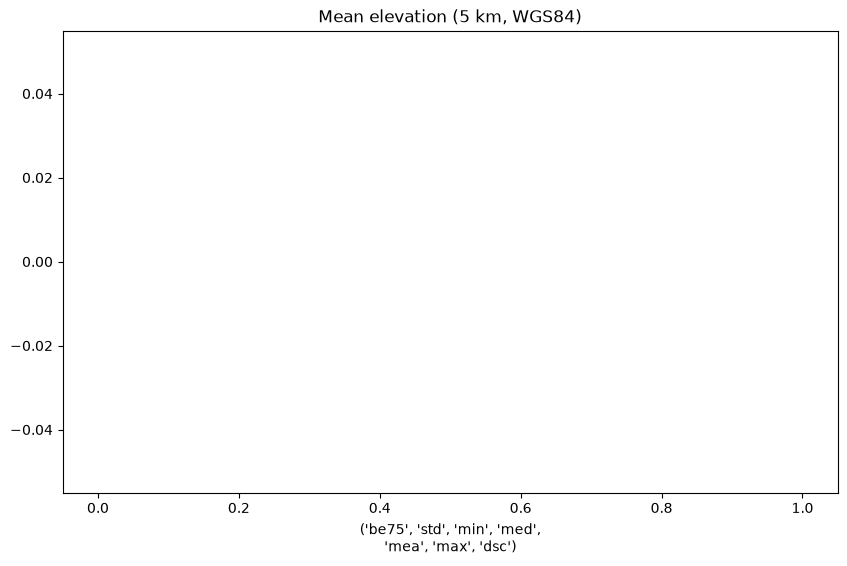

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

elevation_wgs84["mean"].plot(
    ax=ax,
    #cmap="terrain",
    #robust=True,
    #cbar_kwargs={"label": "Elevation (m)"}
)

ax.set_title("Mean elevation (5 km, WGS84)")
plt.show()